## Exploratory Data Analysis (EDA) of Lumbar Spine MRI Dataset

### Dataset overview

This dataset comprises anonymized clinical MRI scans of 515 patients experiencing symptomatic back pain. Each patient may have multiple MRI studies consisting of slices from the lowest three vertebrae and intervertebral discs (IVDs). Axial view slices focus on the last three IVDs, aligning with the spinal curve, while other IVD slices are taken parallel to each other. 

Typically, there are 12 to 15 axial view slices per study, and a total of 48,345 MRI slices are included in the dataset. Most slices have a resolution of 320 x 320 pixels, with some at 320 x 310 pixels, and a precision of 12 bits per pixel. The axial-view slices maintain a uniform thickness of 4 mm and spacing of 0.6875 mm for pixel resolution.

### EDA

In [1]:
import os
import numpy as np
import pandas as pd
import pydicom
import nibabel as nib
import SimpleITK as sitk
import matplotlib.pyplot as plt
from collections import Counter
from datetime import datetime

In [2]:
BASE_PATH = "data/Lumbar_Spine/MRI_Data/01_MRI_Data"
TARGET_SEQUENCE = "T2_TSE_SAG_384_0002"

In [ ]:
def iter_l_spine_series(base_path=BASE_PATH):
    for study_id in sorted(os.listdir(base_path)):
        study_dir = os.path.join(base_path, study_id)
        if not os.path.isdir(study_dir):
            continue

        for item in os.listdir(study_dir):
            if not (item.startswith("L-SPINE_") and os.path.isdir(os.path.join(study_dir, item))):
                continue

            series_root = os.path.join(study_dir, item)
            target_dir = os.path.join(series_root, TARGET_SEQUENCE)
            if os.path.isdir(target_dir):
                yield target_dir, study_id, item

def load_dicom_series(folder):
    files = [os.path.join(folder, f) for f in os.listdir(folder)
             if os.path.isfile(os.path.join(folder, f))]

    dicom_files = []
    for f in files:
        try:
            pydicom.dcmread(f, stop_before_pixels=True)
            dicom_files.append(f)
        except Exception:
            pass

    if not dicom_files:
        return None, None

    datasets = [pydicom.dcmread(f) for f in dicom_files]

    def sort_key(ds):
        return getattr(ds, "InstanceNumber", getattr(ds, "SliceLocation", 0))
    datasets.sort(key=sort_key)

    volume = np.stack([ds.pixel_array for ds in datasets], axis=0).astype(np.float32)

    vmin, vmax = volume.min(), volume.max()
    if vmax > vmin:
        volume = (volume - vmin) / (vmax - vmin)

    return volume, datasets

all_l_spine_volumes = []

genders = []                  # patient gender per study/series
ages = []                     # patient age in years (float), if available
pixel_spacings = []           # (row_spacing, col_spacing)
image_shapes = []             # (rows, cols)
num_slices_list = []          # number of slices in volume
manufacturers = []            # Manufacturer
manufacturer_models = []      # ManufacturerModelName

def parse_patient_age(age_str):
    """
    Parse DICOM PatientAge (e.g. '045Y', '030M', '010D') and return age in years (float).
    If parsing fails, return None.
    """
    if not age_str:
        return None
    try:
        age_str = str(age_str).strip()
        value = float(age_str[:3])
        unit = age_str[3:].upper()
        if unit == "Y":
            return value
        elif unit == "M":
            return value / 12.0
        elif unit == "W":
            return value / 52.0
        elif unit == "D":
            return value / 365.0
        else:
            return value  # fallback
    except Exception:
        return None

for series_path, study_id, series_name in iter_l_spine_series():
    print(f"Loading study {study_id}, series {series_name}, path: {series_path}")
    vol, dsets = load_dicom_series(series_path)
    if vol is None:
        print("  -> No DICOMs found, skipping.")
        continue

    num_slices = vol.shape[0]
    rows, cols = vol.shape[1], vol.shape[2]


    ds0 = dsets[0]

    gender = getattr(ds0, "PatientSex", "Unknown")
    pixel_spacing = getattr(ds0, "PixelSpacing", [None, None])
    age_raw = getattr(ds0, "PatientAge", None)
    age_years = parse_patient_age(age_raw)
    manufacturer = getattr(ds0, "Manufacturer", "Unknown")
    manufacturer_model = getattr(ds0, "ManufacturerModelName", "Unknown")

    genders.append(gender)
    pixel_spacings.append(tuple(pixel_spacing))
    image_shapes.append((rows, cols))
    num_slices_list.append(num_slices)
    ages.append(age_years)
    manufacturers.append(manufacturer)
    manufacturer_models.append(manufacturer_model)

    all_l_spine_volumes.append({
        "study_id": study_id,
        "series_name": series_name,
        "path": series_path,
        "volume": vol,
        "datasets": dsets,
    })

print(f"\nTotal L-SPINE {TARGET_SEQUENCE} series loaded: {len(all_l_spine_volumes)}")


# gender distribution
gender_counts = Counter(genders)
total_cases = sum(gender_counts.values())
print("\nGender distribution:")
for g, c in gender_counts.items():
    frac = c / total_cases if total_cases > 0 else 0
    print(f"  {g}: {c} ({frac:.2%})")

# age statistics
valid_ages = [a for a in ages if a is not None]
if valid_ages:
    age_array = np.array(valid_ages, dtype=float)
    print("\nAge (years):")
    print(f"  Count with age: {len(valid_ages)}")
    print(f"  Mean: {age_array.mean():.1f}")
    print(f"  Std : {age_array.std(ddof=0):.1f}")
    print(f"  Min : {age_array.min():.1f}")
    print(f"  Max : {age_array.max():.1f}")
else:
    print("\nNo valid PatientAge found in series.")

# manufacturer statistics
manu_counts = Counter(manufacturers)
model_counts = Counter(manufacturer_models)

print("\nManufacturer distribution:")
for m, c in manu_counts.items():
    frac = c / len(manufacturers) if manufacturers else 0
    print(f"  {m}: {c} ({frac:.2%})")

print("\nManufacturerModelName distribution:")
for m, c in model_counts.items():
    frac = c / len(manufacturer_models) if manufacturer_models else 0
    print(f"  {m}: {c} ({frac:.2%})")

Loading study 0001, series L-SPINE_LSS_20160309_091629_240000, path: data/Lumbar_Spine/MRI_Data/01_MRI_Data\0001\L-SPINE_LSS_20160309_091629_240000\T2_TSE_SAG_384_0002
Loading study 0002, series L-SPINE_CLINICAL_LIBRARIES_20160621_112938_873000, path: data/Lumbar_Spine/MRI_Data/01_MRI_Data\0002\L-SPINE_CLINICAL_LIBRARIES_20160621_112938_873000\T2_TSE_SAG_384_0002
Loading study 0003, series L-SPINE_LSS_20160411_134646_314000, path: data/Lumbar_Spine/MRI_Data/01_MRI_Data\0003\L-SPINE_LSS_20160411_134646_314000\T2_TSE_SAG_384_0002
Loading study 0004, series L-SPINE_CLINICAL_LIBRARIES_20160526_115018_014000, path: data/Lumbar_Spine/MRI_Data/01_MRI_Data\0004\L-SPINE_CLINICAL_LIBRARIES_20160526_115018_014000\T2_TSE_SAG_384_0002
Loading study 0005, series L-SPINE_CLINICAL_LIBRARIES_20160608_132349_824000, path: data/Lumbar_Spine/MRI_Data/01_MRI_Data\0005\L-SPINE_CLINICAL_LIBRARIES_20160608_132349_824000\T2_TSE_SAG_384_0002
Loading study 0007, series L-SPINE_CLINICAL_LIBRARIES_20160424_144139_

In [4]:
example_ds = all_l_spine_volumes[0]["datasets"][0]
print(example_ds)

Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 210
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: MR Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 1.3.6.1.4.1.9590.100.1.2.68042980612374562918780556041245616239
(0002,0010) Transfer Syntax UID                 UI: Explicit VR Little Endian
(0002,0012) Implementation Class UID            UI: 1.3.6.1.4.1.9590.100.1.3.100.9.4
(0002,0013) Implementation Version Name         SH: 'MATLAB IPT 9.4'
-------------------------------------------------
(0008,0005) Specific Character Set              CS: 'ISO_IR 100'
(0008,0008) Image Type                          CS: ['ORIGINAL', 'PRIMARY', 'M', 'NORM', 'DIS2D', 'FM3_2', 'FIL']
(0008,0012) Instance Creation Date              DA: ''
(0008,0013) Instance Creation Time              TM: '092306.142000'
(0008,0016) SOP Class UID                       UI: MR Image 

In [ ]:
# gender distribution
gender_counts = Counter(genders)
total_patients = sum(gender_counts.values())
print("\nSex distribution:")
for g, c in gender_counts.items():
    print(f"  {g}: {c} ({c/total_patients:.2%})")


# pixel resolution statistics
valid_pixel_spacings = [ps for ps in pixel_spacings if None not in ps]
if valid_pixel_spacings:
    ps_array = np.array(valid_pixel_spacings, dtype=float)
    mean_row_spacing = ps_array[:, 0].mean()
    mean_col_spacing = ps_array[:, 1].mean()
    print("\nPixel spacing (mm):")
    print(f"  Number with valid spacing: {len(valid_pixel_spacings)}")
    print(f"  Mean row spacing: {mean_row_spacing:.4f} mm")
    print(f"  Mean col spacing: {mean_col_spacing:.4f} mm")
    print(f"  Unique spacings: {set(valid_pixel_spacings)}")
else:
    print("\nNo valid PixelSpacing found in series.")

# image size statistics
shapes_array = np.array(image_shapes)
mean_rows = shapes_array[:, 0].mean()
mean_cols = shapes_array[:, 1].mean()
unique_shapes = {tuple(s) for s in image_shapes}
print("\nImage shape (rows x cols):")
print(f"  Mean size: {mean_rows:.1f} x {mean_cols:.1f}")
print(f"  Unique shapes: {unique_shapes}")

# mean number of slices
num_slices_array = np.array(num_slices_list)
print("\nNumber of slices per volume:")
print(f"  Mean: {num_slices_array.mean():.1f}")
print(f"  Min : {num_slices_array.min()}")
print(f"  Max : {num_slices_array.max()}")


Sex distribution:
  M: 285 (63.05%)
  F: 167 (36.95%)

Pixel spacing (mm):
  Number with valid spacing: 452
  Mean row spacing: 0.7297 mm
  Mean col spacing: 0.7297 mm
  Unique spacings: {('0.72916668653488', '0.72916668653488'), ('0.734375', '0.734375'), ('0.67708331346512', '0.67708331346512'), ('0.875', '0.875')}

Image shape (rows x cols):
  Mean size: 383.7 x 383.7
  Unique shapes: {(384, 384), (320, 320)}

Number of slices per volume:
  Mean: 15.4
  Min : 13
  Max : 30


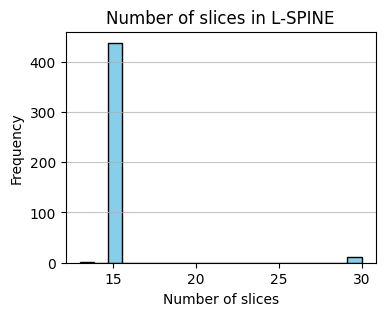

In [6]:
# histogram of number of slices
plt.figure(figsize=(4, 3))
plt.hist(num_slices_array, bins=20, color='skyblue', edgecolor='black')
plt.title(f'Number of slices in L-SPINE')
plt.xlabel('Number of slices')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

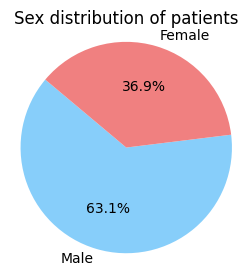

In [26]:
# pie chart of gender
labels = ["Male", "Female"]
sizes = gender_counts.values()
plt.figure(figsize=(3, 3))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=['lightskyblue','lightcoral',  'lightgreen'])   
plt.title('Sex distribution of patients')
plt.axis('equal')
plt.show()

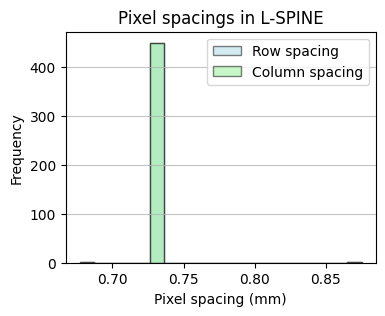

In [28]:
# histogram of pixel spacings
if valid_pixel_spacings:
    plt.figure(figsize=(4, 3))
    plt.hist(ps_array[:, 0], bins=20, alpha=0.5, label='Row spacing', color='lightblue', edgecolor='black')
    plt.hist(ps_array[:, 1], bins=20, alpha=0.5, label='Column spacing', color='lightgreen', edgecolor='black')
    plt.title(f'Pixel spacings in L-SPINE')
    plt.xlabel('Pixel spacing (mm)')
    plt.ylabel('Frequency')
    plt.legend()
    plt.grid(axis='y', alpha=0.75)
    plt.show()

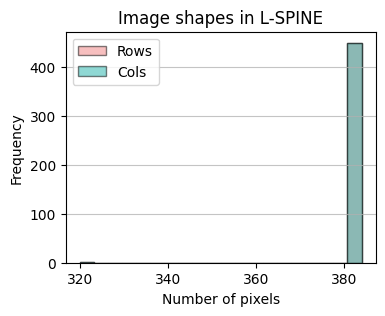

In [30]:
# histogram of image shapes
rows = shapes_array[:, 0]
cols = shapes_array[:, 1]
plt.figure(figsize=(4, 3))
plt.hist(rows, bins=20, alpha=0.5, label='Rows', color='lightcoral', edgecolor='black')
plt.hist(cols, bins=20, alpha=0.5, label='Cols', color='lightseagreen', edgecolor='black')
plt.title(f'Image shapes in L-SPINE')
plt.xlabel('Number of pixels')
plt.ylabel('Frequency')
plt.legend()
plt.grid(axis='y', alpha=0.75)
plt.show()

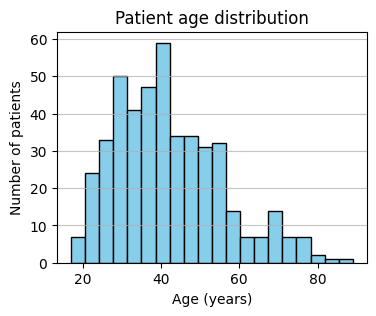

In [31]:
# age histogram
if valid_ages:
    plt.figure(figsize=(4, 3))
    plt.hist(age_array, bins=20, color='skyblue', edgecolor='black')
    plt.title('Patient age distribution')
    plt.xlabel('Age (years)')
    plt.ylabel('Number of patients')
    plt.grid(axis='y', alpha=0.75)
    plt.show()

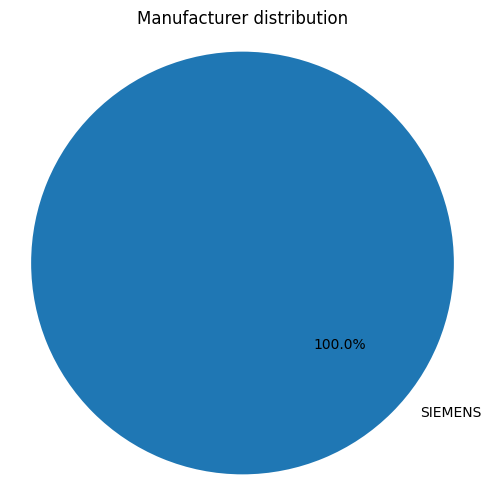

In [32]:
# manufacturer distribution
manu_counts = Counter(manufacturers)
labels = list(manu_counts.keys())
sizes = manu_counts.values()
plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)   
plt.title('Manufacturer distribution')
plt.axis('equal')
plt.show()

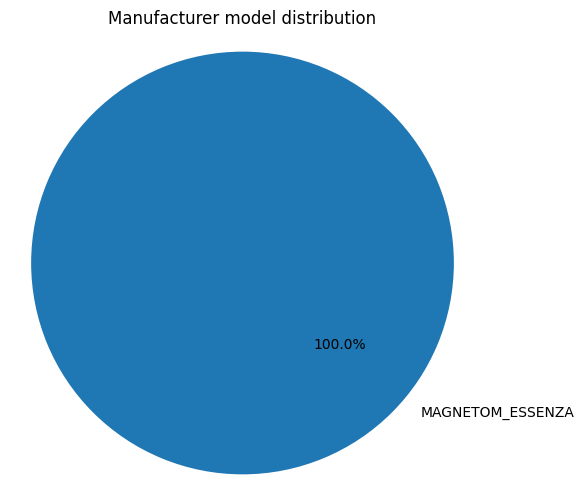

In [33]:
# manufacturer model distribution
model_counts = Counter(manufacturer_models)
labels = list(model_counts.keys())
sizes = model_counts.values()
plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)   
plt.title('Manufacturer model distribution')
plt.axis('equal')
plt.show()


### NIfTI visualization (slices analysis)

In [8]:
NIFTI_OUT_DIR = "Data/Lumbar_Spine_NIfTI_T2_TSE_SAG_384_0002"
os.makedirs(NIFTI_OUT_DIR, exist_ok=True)

print("\nExporting series to NIfTI...")

for entry in all_l_spine_volumes:
    study_id = entry["study_id"]
    series_name = entry["series_name"]
    volume = entry["volume"]
    dsets = entry["datasets"]

    ds0 = dsets[0]

    pixel_spacing = getattr(ds0, "PixelSpacing", [1.0, 1.0])
    row_spacing, col_spacing = float(pixel_spacing[0]), float(pixel_spacing[1])

    slice_thickness = float(getattr(ds0, "SliceThickness", 1.0))

    affine = np.diag([col_spacing, row_spacing, slice_thickness, 1.0])

    # NIfTI expects (X, Y, Z); volume is (Z, Y, X) -> transpose
    volume_zyx = volume  # (z, y, x)
    volume_xyz = np.transpose(volume_zyx, (2, 1, 0))  # (x, y, z)

    nifti_img = nib.Nifti1Image(volume_xyz, affine)

   
    safe_series = series_name.replace("/", "_")
    fname = f"{study_id}_{safe_series}_{TARGET_SEQUENCE}.nii.gz"
    out_path = os.path.join(NIFTI_OUT_DIR, fname)

    nib.save(nifti_img, out_path)
    print(f"  Saved NIfTI: {out_path}")


Exporting series to NIfTI...
  Saved NIfTI: Data/Lumbar_Spine_NIfTI_T2_TSE_SAG_384_0002\0001_L-SPINE_LSS_20160309_091629_240000_T2_TSE_SAG_384_0002.nii.gz
  Saved NIfTI: Data/Lumbar_Spine_NIfTI_T2_TSE_SAG_384_0002\0002_L-SPINE_CLINICAL_LIBRARIES_20160621_112938_873000_T2_TSE_SAG_384_0002.nii.gz
  Saved NIfTI: Data/Lumbar_Spine_NIfTI_T2_TSE_SAG_384_0002\0003_L-SPINE_LSS_20160411_134646_314000_T2_TSE_SAG_384_0002.nii.gz
  Saved NIfTI: Data/Lumbar_Spine_NIfTI_T2_TSE_SAG_384_0002\0004_L-SPINE_CLINICAL_LIBRARIES_20160526_115018_014000_T2_TSE_SAG_384_0002.nii.gz
  Saved NIfTI: Data/Lumbar_Spine_NIfTI_T2_TSE_SAG_384_0002\0005_L-SPINE_CLINICAL_LIBRARIES_20160608_132349_824000_T2_TSE_SAG_384_0002.nii.gz
  Saved NIfTI: Data/Lumbar_Spine_NIfTI_T2_TSE_SAG_384_0002\0007_L-SPINE_CLINICAL_LIBRARIES_20160424_144139_347000_T2_TSE_SAG_384_0002.nii.gz
  Saved NIfTI: Data/Lumbar_Spine_NIfTI_T2_TSE_SAG_384_0002\0009_L-SPINE_CLINICAL_LIBRARIES_20160712_142958_190000_T2_TSE_SAG_384_0002.nii.gz
  Saved NIfTI

Loaded NIfTI: 0575_L-SPINE_LSS_20151014_123158_358000_T2_TSE_SAG_384_0002.nii.gz
Shape: (384, 384, 15)
Affine:
[[0.72916669 0.         0.         0.        ]
 [0.         0.72916669 0.         0.        ]
 [0.         0.         4.         0.        ]
 [0.         0.         0.         1.        ]]


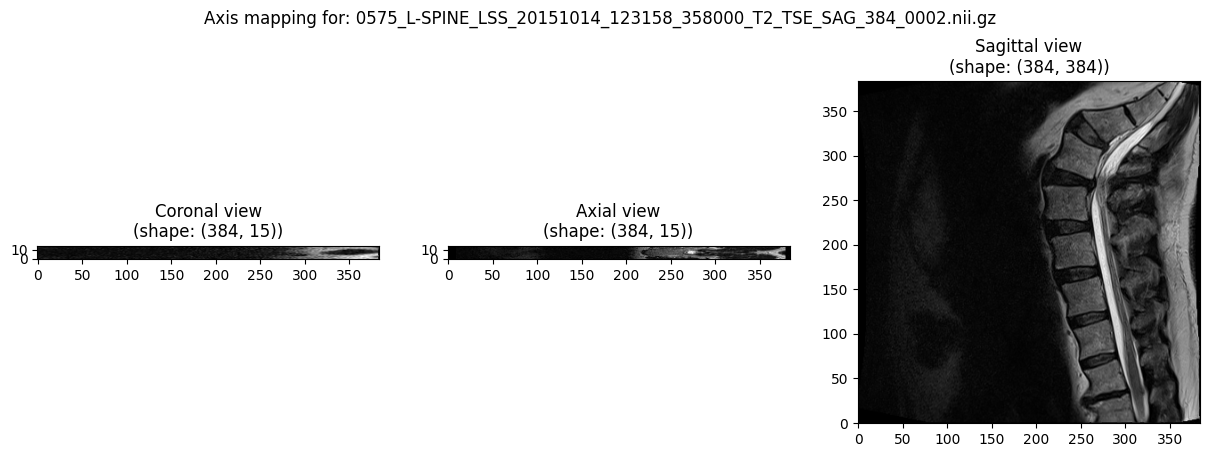

In [ ]:
# we decided to load the last saved NIfTI file for verification
last_nifti_path = out_path 
loaded_nifti = nib.load(last_nifti_path)
loaded_data = loaded_nifti.get_fdata()
shape = loaded_data.shape


print(f"Loaded NIfTI: {os.path.basename(last_nifti_path)}")
print(f"Shape: {loaded_data.shape}")
print(f"Affine:\n{loaded_nifti.affine}")

fig, ax = plt.subplots(1, 3, figsize=(15, 5))

# slice 1 -- CORONAL 
ax[0].imshow(loaded_data[shape[0]//2, :, :].T, cmap='gray', origin='lower')
ax[0].set_title(f"Coronal view\n(shape: {loaded_data[shape[0]//2, :, :].shape})")

# slice 2 -- AXIAL 
ax[1].imshow(loaded_data[:, shape[1]//2, :].T, cmap='gray', origin='lower')
ax[1].set_title(f"Axial view\n(shape: {loaded_data[:, shape[1]//2, :].shape})")

# slice 3 -- SAGITTAL
ax[2].imshow(loaded_data[:, :, shape[2]//2].T, cmap='gray', origin='lower')
ax[2].set_title(f"Sagittal view\n(shape: {loaded_data[:, :, shape[2]//2].shape})")

plt.suptitle(f"Axis mapping for: {os.path.basename(last_nifti_path)}")
plt.show()

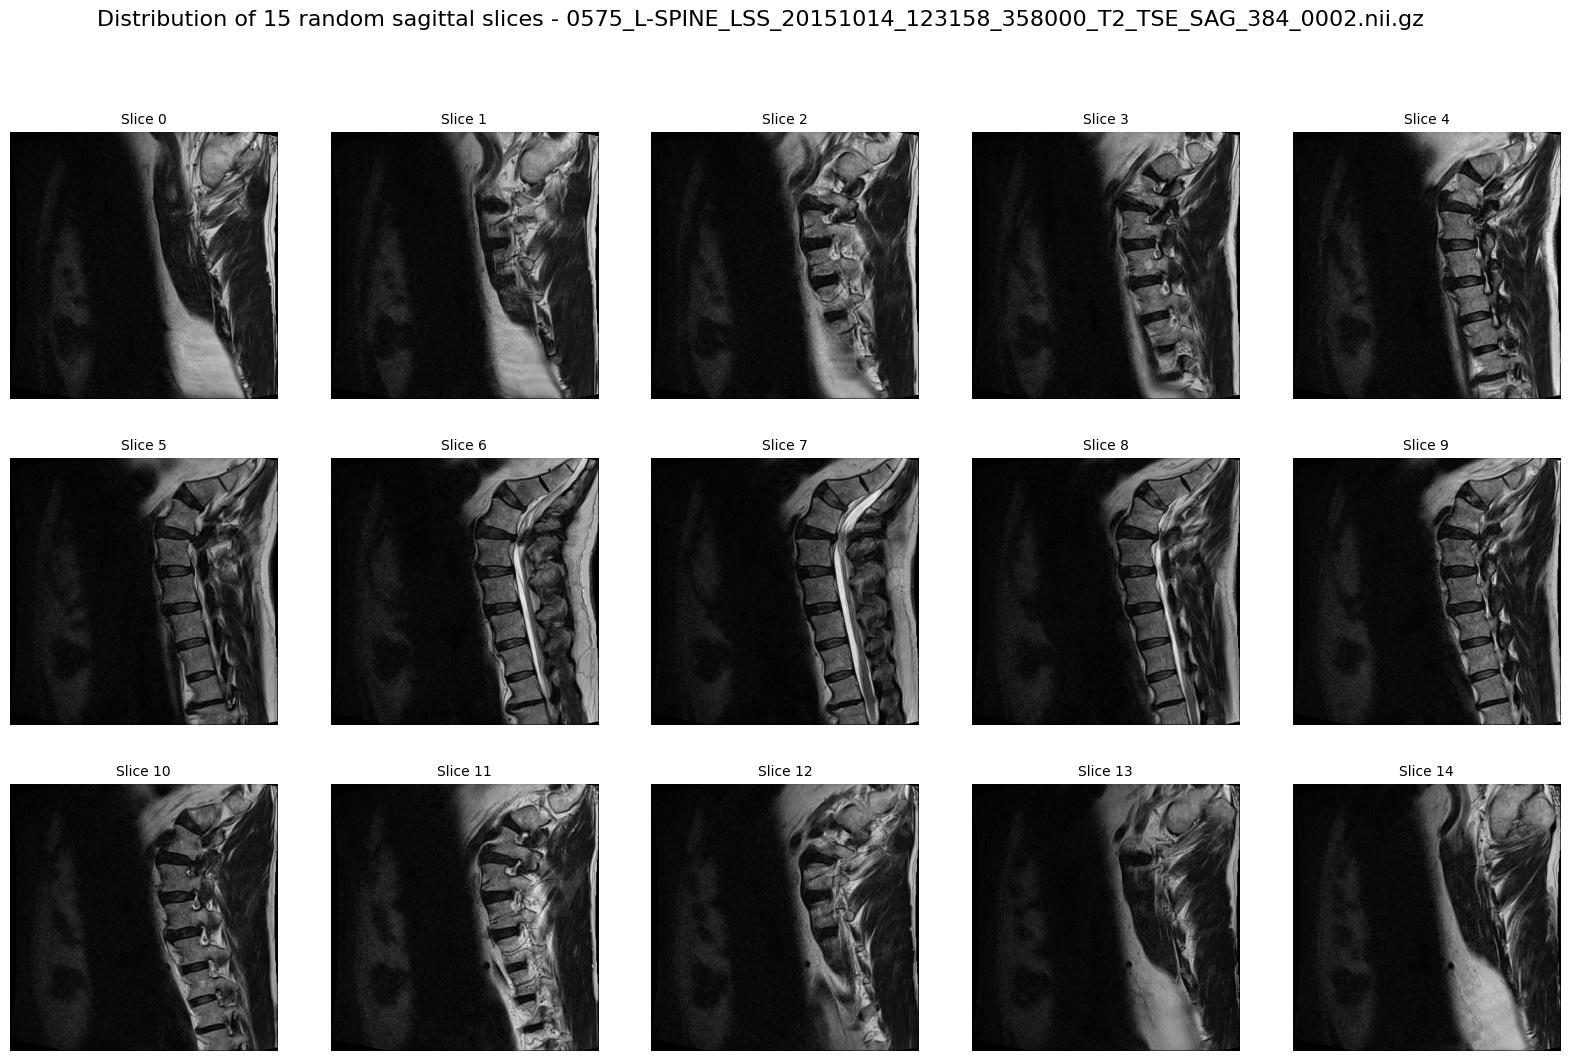

In [24]:
num_slices = loaded_data.shape[2]

cols = 5
rows = (num_slices // cols) 

fig, axes = plt.subplots(rows, cols, figsize=(20, rows * 4))
axes = axes.flatten()

for i in range(len(axes)):
    if i < num_slices:

        axes[i].imshow(loaded_data[:, :, i].T, cmap='gray', origin='lower')
        axes[i].set_title(f"Slice {i}", fontsize=10)
        axes[i].axis('off')

plt.suptitle(f"Distribution of 15 random sagittal slices - {os.path.basename(last_nifti_path)}", fontsize=16)
plt.show()